# Job Market Analysis Using Web Scraping

## Project Overview

This project demonstrates how Python can be used to collect job-market information from online job portals through web scraping.

The scraped data is cleaned, structured, and analyzed to identify patterns in job titles, companies, locations, experience requirements, salaries, skills, industries, and employment types.

A secondary section demonstrates scraping stock-market news articles to show how web scraping can be applied to financial information.

## 🎯 Project Objective

The main objective of this project is to collect and analyze Data Analyst job-market information using Python-based web scraping.

### Key Objectives

- 🌐 Scrape job postings from online job portals.
- 📋 Extract job title, company, location, salary, experience, skills, and other details.
- 🧹 Clean and organize the scraped data using Pandas.
- 📊 Analyze job-market trends and hiring requirements.
- 💼 Identify the most frequently requested Data Analyst skills.
- 📍 Analyze job opportunities across different locations.
- 💰 Explore salary and experience patterns.
- 🏢 Identify companies and industries hiring Data Analysts.
- 📈 Create professional visualizations to communicate insights.
- 📰 Demonstrate web scraping on stock-market news as a secondary use case.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
response = requests.get("https://www.google.com")

print("Status Code:", response.status_code)

Status Code: 200


In [4]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/127.0.0.0 Safari/537.36"
}

print("Headers created successfully!")

Headers created successfully!


In [6]:
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

timesjobs_url = "https://www.timesjobs.com/candidate/job-search.html?searchType=personalizedSearch&from=submit&txtKeywords=Data%20Analyst&txtLocation=India"

response = requests.get(
    timesjobs_url,
    headers=headers,
    verify=False,
    timeout=30
)

print("Status Code:", response.status_code)
print("Page Length:", len(response.text))

Status Code: 200
Page Length: 13803


In [7]:
soup = BeautifulSoup(response.text, "html.parser")

job_postings = soup.find_all("li", class_="clearfix job-bx wht-shd-bx")

print("Number of job postings found:", len(job_postings))

Number of job postings found: 0


In [8]:
print(response.text[:3000])

<!DOCTYPE html><html lang="en" class="__className_b1fcf8"><head><meta charSet="utf-8"/><meta name="viewport" content="width=device-width, initial-scale=1"/><link rel="preload" href="/_next/static/media/68180864d7f93f02.p.woff2" as="font" crossorigin="" type="font/woff2"/><link rel="stylesheet" href="/_next/static/css/586f4d4b34cbd2e8.css" data-precedence="next"/><link rel="stylesheet" href="/_next/static/css/53e9cc8547db2e40.css" data-precedence="next"/><link rel="preload" as="script" fetchPriority="low" href="/_next/static/chunks/webpack-e22cd055d377033c.js"/><script src="/_next/static/chunks/fd9d1056-d29e7d003e442815.js" async=""></script><script src="/_next/static/chunks/2117-b3ef893d9ae82b72.js" async=""></script><script src="/_next/static/chunks/main-app-98094f4523af37dc.js" async=""></script><script src="/_next/static/chunks/5878-cc834b8d2a042342.js" async=""></script><script src="/_next/static/chunks/2972-33c0decb73b559bf.js" async=""></script><script src="/_next/static/chunks/4

In [9]:
# Inspect the scripts embedded in the webpage

scripts = soup.find_all("script")

print("Number of script tags:", len(scripts))

for i, script in enumerate(scripts):
    script_text = script.get_text()
    
    if "Data Analyst" in script_text or "jobTitle" in script_text or "companyName" in script_text:
        print("\n--- Script", i, "---")
        print("Length:", len(script_text))
        print(script_text[:1000])

Number of script tags: 29


In [10]:
# Look for job-related data inside the webpage scripts

for i, script in enumerate(soup.find_all("script")):
    text = script.get_text()

    if any(word in text.lower() for word in ["data analyst", "jobtitle", "companyname", "job-search"]):
        print(f"\n--- Script {i} ---")
        print("Length:", len(text))
        print(text[:2000])


--- Script 25 ---
Length: 2252
self.__next_f.push([1,"4:I[12846,[],\"\"]\n6:I[19107,[],\"ClientPageRoot\"]\n7:I[42765,[\"5878\",\"static/chunks/5878-cc834b8d2a042342.js\",\"2972\",\"static/chunks/2972-33c0decb73b559bf.js\",\"4307\",\"static/chunks/4307-ad9f678c23f9305b.js\",\"6638\",\"static/chunks/6638-4e90f4700310eebb.js\",\"8924\",\"static/chunks/8924-5d9def05283cc787.js\",\"7487\",\"static/chunks/7487-6643b0de46ff2e22.js\",\"5453\",\"static/chunks/5453-9ce7a3311cc77bab.js\",\"3134\",\"static/chunks/3134-fccc2ea2e1df69b9.js\",\"8687\",\"static/chunks/8687-6cfb5e9af7fb3f2b.js\",\"6541\",\"static/chunks/6541-b5246a1a502f7d02.js\",\"5036\",\"static/chunks/5036-dde34c9ee172c0ae.js\",\"2765\",\"static/chunks/2765-331984c163ae728a.js\",\"8204\",\"static/chunks/app/job-search/page-dda3be048ed12a0b.js\"],\"default\",1]\n8:I[4707,[],\"\"]\n9:I[36423,[],\"\"]\na:I[88003,[\"5878\",\"static/chunks/5878-cc834b8d2a042342.js\",\"2972\",\"static/chunks/2972-33c0decb73b559bf.js\",\"4307\",\"static/

In [11]:
# Check for JSON-LD structured data in the webpage

json_ld_scripts = soup.find_all(
    "script",
    type="application/ld+json"
)

print("JSON-LD blocks found:", len(json_ld_scripts))

for i, script in enumerate(json_ld_scripts):
    print(f"\n--- JSON-LD Block {i + 1} ---")
    print(script.get_text()[:2000])

JSON-LD blocks found: 0


In [12]:
# Extract visible text from the TimesJobs page

page_text = soup.get_text(" ", strip=True)

print(page_text[:5000])

Cand - Job Search Platform


In [13]:
# Check for Next.js page data

next_data = soup.find("script", id="__NEXT_DATA__")

if next_data:
    print("✅ __NEXT_DATA__ found!")
    print("Length:", len(next_data.get_text()))
    print(next_data.get_text()[:3000])
else:
    print("❌ __NEXT_DATA__ not found")

❌ __NEXT_DATA__ not found


In [14]:
# Search the webpage source for possible API endpoints

api_urls = re.findall(
    r'https?://[^"\']+',
    response.text
)

print("Possible URLs found:", len(api_urls))

for url in api_urls:
    if any(word in url.lower() for word in ["api", "job", "search"]):
        print(url[:500])

Possible URLs found: 8
https://www.timesjobs.com/images/timesjobs-logo.jpg
https://www.timesjobs.com/images/timesjobs-logo.jpg
https://www.timesjobs.com/images/timesjobs-logo.jpg\
https://www.timesjobs.com/images/timesjobs-logo.jpg\


In [15]:
# Find JavaScript files loaded by the TimesJobs page

script_urls = []

for script in soup.find_all("script", src=True):
    src = script.get("src")
    
    if src.startswith("/"):
        src = "https://www.timesjobs.com" + src
    
    script_urls.append(src)

print("JavaScript files found:", len(script_urls))

for url in script_urls[:20]:
    print(url)

JavaScript files found: 22
https://www.timesjobs.com/_next/static/chunks/fd9d1056-d29e7d003e442815.js
https://www.timesjobs.com/_next/static/chunks/2117-b3ef893d9ae82b72.js
https://www.timesjobs.com/_next/static/chunks/main-app-98094f4523af37dc.js
https://www.timesjobs.com/_next/static/chunks/5878-cc834b8d2a042342.js
https://www.timesjobs.com/_next/static/chunks/2972-33c0decb73b559bf.js
https://www.timesjobs.com/_next/static/chunks/4307-ad9f678c23f9305b.js
https://www.timesjobs.com/_next/static/chunks/6638-4e90f4700310eebb.js
https://www.timesjobs.com/_next/static/chunks/8924-5d9def05283cc787.js
https://www.timesjobs.com/_next/static/chunks/7487-6643b0de46ff2e22.js
https://www.timesjobs.com/_next/static/chunks/5453-9ce7a3311cc77bab.js
https://www.timesjobs.com/_next/static/chunks/3134-fccc2ea2e1df69b9.js
https://www.timesjobs.com/_next/static/chunks/8687-6cfb5e9af7fb3f2b.js
https://www.timesjobs.com/_next/static/chunks/6541-b5246a1a502f7d02.js
https://www.timesjobs.com/_next/static/chu

In [16]:
# Find the Job Search JavaScript file

job_search_script = [
    url for url in script_urls
    if "/job-search/page-" in url
]

print("Job Search JavaScript files found:", len(job_search_script))

for url in job_search_script:
    print(url)

Job Search JavaScript files found: 1
https://www.timesjobs.com/_next/static/chunks/app/job-search/page-dda3be048ed12a0b.js


In [17]:
import os

# Check files in the current project folder
files = os.listdir()

print("Files in current folder:\n")

for file in files:
    print(file)

Files in current folder:

.ipynb_checkpoints
Job_Market_Web_Scraping_Analysis.ipynb


In [19]:
# Search nearby folders for the original web-scraping notebook

import os

matches = []

for root, dirs, files in os.walk(".."):
    for file in files:
        if "Job_market_analysis" in file:
            matches.append(os.path.join(root, file))

print("Matching files found:", len(matches))

for file in matches:
    print(file)

Matching files found: 2
..\AppData\Roaming\Microsoft\Windows\Recent\Job_market_analysis_partA_+_stockmarket_webscarping.lnk
..\Downloads\Job_market_analysis_partA_+_stockmarket_webscarping.ipynb


In [20]:
# Find the original TimesJobs CSV in the Downloads folder

import os
import glob

downloads_folder = os.path.join(os.path.expanduser("~"), "Downloads")

csv_files = glob.glob(
    os.path.join(downloads_folder, "*data*analyst*timesjobs*.csv")
)

print("CSV files found:", len(csv_files))

for file in csv_files:
    print(file)

CSV files found: 0


In [21]:
# Locate the original web-scraping notebook

import os
import json

original_notebook = os.path.join(
    os.path.expanduser("~"),
    "Downloads",
    "Job_market_analysis_partA_+_stockmarket_webscarping.ipynb"
)

print("Notebook exists:", os.path.exists(original_notebook))
print("Path:", original_notebook)

Notebook exists: True
Path: C:\Users\hp\Downloads\Job_market_analysis_partA_+_stockmarket_webscarping.ipynb


In [22]:
# Inspect the original notebook for the TimesJobs dataset

import json
import os

with open(original_notebook, "r", encoding="utf-8") as f:
    original_data = json.load(f)

print("Original notebook loaded successfully!")
print("Total cells:", len(original_data["cells"]))

print("\nSearching for the TimesJobs dataset code...\n")

for i, cell in enumerate(original_data["cells"]):
    source = "".join(cell.get("source", []))
    
    if "data_analyst_timesjobs" in source or "scrape_multiple_job_posts" in source:
        print("=" * 70)
        print("CELL:", i)
        print(source[:3000])
        print("=" * 70)

Original notebook loaded successfully!
Total cells: 84

Searching for the TimesJobs dataset code...

CELL: 16
import requests
from bs4 import BeautifulSoup
import pandas as pd

def scrape_multiple_job_posts(urls):
    # List to store data from each job post
    job_data_list = []

    for url in urls:
        # Fetch the HTML content from the URL
        response = requests.get(url, headers=head)

        # Check if the request was successful
        if response.status_code == 200:
            content = response.content

            # Parse the HTML content with BeautifulSoup
            soup = BeautifulSoup(content, 'lxml')

            # Extract job details
            try:
                job_title = soup.find("h1", {"class": "!mb-0 line-clamp-2 text-lg font-bold md:!text-2xl"}).text.strip()
            except AttributeError:
                job_title = None

            try:
                company_name = soup.find("a", {"class": "line-clamp-2 text-sm font-normal !text-brand-primar

In [23]:
# Check whether the original notebook contains the scraped DataFrame output

import json

with open(original_notebook, "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    source = "".join(cell.get("source", []))

    if "df = scrape_multiple_job_posts(job_urls)" in source:
        print("✅ Found scraping execution cell:", i)
        print("Output types saved in this cell:")

        outputs = cell.get("outputs", [])

        for j, output in enumerate(outputs):
            print(f"  Output {j + 1}: {output.get('output_type')}")
            
            if "data" in output:
                print("  Data formats:", list(output["data"].keys()))
            if "text" in output:
                print("  Text preview:", "".join(output["text"])[:500])

✅ Found scraping execution cell: 63
Output types saved in this cell:


In [25]:
# Extract the saved job DataFrame without using pandas read_html

from bs4 import BeautifulSoup
import pandas as pd
import json

with open(original_notebook, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Cell 65 contains the saved DataFrame preview
preview_cell = nb["cells"][65]

html_output = None

for output in preview_cell.get("outputs", []):
    if "text/html" in output.get("data", {}):
        html_output = "".join(output["data"]["text/html"])
        break

if html_output:
    # Parse the HTML table
    table_soup = BeautifulSoup(html_output, "html.parser")
    table = table_soup.find("table")

    headers = [
        th.get_text(strip=True)
        for th in table.find("thead").find_all("th")
    ]

    rows = []

    for tr in table.find("tbody").find_all("tr"):
        cells = [
            td.get_text(" ", strip=True)
            for td in tr.find_all(["th", "td"])
        ]
        rows.append(cells)

    job_df = pd.DataFrame(rows, columns=headers)

    # Remove the old index column
    if "" in job_df.columns:
        job_df = job_df.drop(columns=[""])

    print("✅ Dataset extracted successfully!")
    print("Rows:", len(job_df))
    print("Columns:", len(job_df.columns))

    display(job_df.head())

else:
    print("❌ Could not find the saved DataFrame.")

✅ Dataset extracted successfully!
Rows: 50
Columns: 14


,Job Title,Company Name,Location,Years of Experience,Salary,Job Description,Skills,Function,Industry,Specialization,Role,Qualifications,Employment Type,URL
0,Data Analyst,RELIANCE INDUSTRIES LIMITED\n \t\...,"location_on\n\t Pune (Maharashtra), Tri...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,₹\n Rs 8.10 - 19.00 Lacs p.a.,\nJob Description\nData Analyst Job Responsibi...,", Key Skills, , Data Analyst \nBusiness analys...",Job Function:\nFront Office Staff/Secretarial/...,Accounting-Tax/Consulting,"Data entry,Front Office,Personal/Secretarial,R...",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
1,Data Analyst,Jayant Govind kasar,"location_on\n\t Ropar (Punjab), Coimbat...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 1 to ...,₹\n Rs 3.10 - 9.55 Lacs p.a.,\nJob Description\nDeepa Mahori Consultants is...,", Key Skills, , Advanced analytical knowledge ...","Job Function:\nAdministration,Sales/Business D...","Construction/Cement/Metal/Steel/Iron, Project...","Supplies Co-ordination,Relationship/Account Se...",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
2,Data Analyst,Ajay Vijay Chatur,"location_on\n\t Mumbai (Maharashtra), A...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 4 to ...,₹\n Rs 11.15 - 20.05 Lacs p.a.,\nJob Description\nData Analyst Job Responsibi...,", Key Skills, , Data Analyst \nAdvanced analyt...",Job Function:\nAccounting/Tax/Company Secretar...,Manufacturing/Industrial,"Audit & Risk,Data entry,Front Office,Stenography",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
3,Data Analyst,Jayant Govind kasar,location_on\n\t Bengaluru/ Bangalore (K...,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,₹\n As per Industry Standards,\nJob Description\nCompany requires candidate ...,", Key Skills, , Data Management \nData Analyst...",Job Function:\nAccounting/Tax/Company Secretar...,"Engineering/Projects, Projects/Infrastructure...","Accounting/Financial Products ,Engineering/Man...","Auditing Manager, Management Accountant, Taxat...",Qualification:\n\n\n\n Any ...,Any Graduate,https://www.timesjobs.com/job-detail/data-anal...
4,Data Analyst,HR Empower Consultancy,"location_on\n\t Sonepat (Haryana), Yamu...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 0 to ...,₹\n As per Industry Standards,\nJob Description\nData analyst job descriptio...,", Key Skills, , SQL \nframeworks \nXML \nJavaS...",Job Function:\nIT Software : Software Products...,IT-Software,Data Warehousing,BE/ B.Tech (Engineering)\n ...,BE/ B.Tech (Engineering)\n ...,Employment Type:\n \t\t \tPart Time,https://www.timesjobs.com/job-detail/data-anal...


In [26]:
# Verify and save the extracted job-market dataset

print("Dataset shape:", job_df.shape)

print("\nColumn names:")
print(job_df.columns.tolist())

print("\nFirst 5 job records:")
display(job_df.head())

# Save the dataset in our current project folder
job_df.to_csv("data_analyst_timesjobs.csv", index=False)

print("\n✅ Dataset saved as: data_analyst_timesjobs.csv")

Dataset shape: (50, 14)

Column names:
['Job Title', 'Company Name', 'Location', 'Years of Experience', 'Salary', 'Job Description', 'Skills', 'Function', 'Industry', 'Specialization', 'Role', 'Qualifications', 'Employment Type', 'URL']

First 5 job records:


,Job Title,Company Name,Location,Years of Experience,Salary,Job Description,Skills,Function,Industry,Specialization,Role,Qualifications,Employment Type,URL
0,Data Analyst,RELIANCE INDUSTRIES LIMITED\n \t\...,"location_on\n\t Pune (Maharashtra), Tri...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,₹\n Rs 8.10 - 19.00 Lacs p.a.,\nJob Description\nData Analyst Job Responsibi...,", Key Skills, , Data Analyst \nBusiness analys...",Job Function:\nFront Office Staff/Secretarial/...,Accounting-Tax/Consulting,"Data entry,Front Office,Personal/Secretarial,R...",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
1,Data Analyst,Jayant Govind kasar,"location_on\n\t Ropar (Punjab), Coimbat...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 1 to ...,₹\n Rs 3.10 - 9.55 Lacs p.a.,\nJob Description\nDeepa Mahori Consultants is...,", Key Skills, , Advanced analytical knowledge ...","Job Function:\nAdministration,Sales/Business D...","Construction/Cement/Metal/Steel/Iron, Project...","Supplies Co-ordination,Relationship/Account Se...",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
2,Data Analyst,Ajay Vijay Chatur,"location_on\n\t Mumbai (Maharashtra), A...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 4 to ...,₹\n Rs 11.15 - 20.05 Lacs p.a.,\nJob Description\nData Analyst Job Responsibi...,", Key Skills, , Data Analyst \nAdvanced analyt...",Job Function:\nAccounting/Tax/Company Secretar...,Manufacturing/Industrial,"Audit & Risk,Data entry,Front Office,Stenography",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
3,Data Analyst,Jayant Govind kasar,location_on\n\t Bengaluru/ Bangalore (K...,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,₹\n As per Industry Standards,\nJob Description\nCompany requires candidate ...,", Key Skills, , Data Management \nData Analyst...",Job Function:\nAccounting/Tax/Company Secretar...,"Engineering/Projects, Projects/Infrastructure...","Accounting/Financial Products ,Engineering/Man...","Auditing Manager, Management Accountant, Taxat...",Qualification:\n\n\n\n Any ...,Any Graduate,https://www.timesjobs.com/job-detail/data-anal...
4,Data Analyst,HR Empower Consultancy,"location_on\n\t Sonepat (Haryana), Yamu...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 0 to ...,₹\n As per Industry Standards,\nJob Description\nData analyst job descriptio...,", Key Skills, , SQL \nframeworks \nXML \nJavaS...",Job Function:\nIT Software : Software Products...,IT-Software,Data Warehousing,BE/ B.Tech (Engineering)\n ...,BE/ B.Tech (Engineering)\n ...,Employment Type:\n \t\t \tPart Time,https://www.timesjobs.com/job-detail/data-anal...



✅ Dataset saved as: data_analyst_timesjobs.csv


In [27]:
# Load the scraped job-market dataset

job_df = pd.read_csv("data_analyst_timesjobs.csv")

print("✅ Dataset loaded successfully!")
print("Rows:", job_df.shape[0])
print("Columns:", job_df.shape[1])

print("\nColumn names:")
print(job_df.columns.tolist())

print("\nDataset preview:")
display(job_df.head())

✅ Dataset loaded successfully!
Rows: 50
Columns: 14

Column names:
['Job Title', 'Company Name', 'Location', 'Years of Experience', 'Salary', 'Job Description', 'Skills', 'Function', 'Industry', 'Specialization', 'Role', 'Qualifications', 'Employment Type', 'URL']

Dataset preview:


,Job Title,Company Name,Location,Years of Experience,Salary,Job Description,Skills,Function,Industry,Specialization,Role,Qualifications,Employment Type,URL
0,Data Analyst,RELIANCE INDUSTRIES LIMITED\n \t\...,"location_on\n\t Pune (Maharashtra), Tri...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,₹\n Rs 8.10 - 19.00 Lacs p.a.,\nJob Description\nData Analyst Job Responsibi...,", Key Skills, , Data Analyst \nBusiness analys...",Job Function:\nFront Office Staff/Secretarial/...,Accounting-Tax/Consulting,"Data entry,Front Office,Personal/Secretarial,R...",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
1,Data Analyst,Jayant Govind kasar,"location_on\n\t Ropar (Punjab), Coimbat...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 1 to ...,₹\n Rs 3.10 - 9.55 Lacs p.a.,\nJob Description\nDeepa Mahori Consultants is...,", Key Skills, , Advanced analytical knowledge ...","Job Function:\nAdministration,Sales/Business D...","Construction/Cement/Metal/Steel/Iron, Project...","Supplies Co-ordination,Relationship/Account Se...",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
2,Data Analyst,Ajay Vijay Chatur,"location_on\n\t Mumbai (Maharashtra), A...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 4 to ...,₹\n Rs 11.15 - 20.05 Lacs p.a.,\nJob Description\nData Analyst Job Responsibi...,", Key Skills, , Data Analyst \nAdvanced analyt...",Job Function:\nAccounting/Tax/Company Secretar...,Manufacturing/Industrial,"Audit & Risk,Data entry,Front Office,Stenography",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
3,Data Analyst,Jayant Govind kasar,location_on\n\t Bengaluru/ Bangalore (K...,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,₹\n As per Industry Standards,\nJob Description\nCompany requires candidate ...,", Key Skills, , Data Management \nData Analyst...",Job Function:\nAccounting/Tax/Company Secretar...,"Engineering/Projects, Projects/Infrastructure...","Accounting/Financial Products ,Engineering/Man...","Auditing Manager, Management Accountant, Taxat...",Qualification:\n\n\n\n Any ...,Any Graduate,https://www.timesjobs.com/job-detail/data-anal...
4,Data Analyst,HR Empower Consultancy,"location_on\n\t Sonepat (Haryana), Yamu...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 0 to ...,₹\n As per Industry Standards,\nJob Description\nData analyst job descriptio...,", Key Skills, , SQL \nframeworks \nXML \nJavaS...",Job Function:\nIT Software : Software Products...,IT-Software,Data Warehousing,BE/ B.Tech (Engineering)\n ...,BE/ B.Tech (Engineering)\n ...,Employment Type:\n \t\t \tPart Time,https://www.timesjobs.com/job-detail/data-anal...


In [28]:
# Data Quality Check

print("📊 DATASET OVERVIEW")
print("-" * 50)

print("Rows:", job_df.shape[0])
print("Columns:", job_df.shape[1])

print("\n🔎 DATA TYPES")
print("-" * 50)
print(job_df.dtypes)

print("\n❓ MISSING VALUES")
print("-" * 50)
print(job_df.isnull().sum())

print("\n🔁 DUPLICATE ROWS")
print("-" * 50)
print("Duplicate rows:", job_df.duplicated().sum())

📊 DATASET OVERVIEW
--------------------------------------------------
Rows: 50
Columns: 14

🔎 DATA TYPES
--------------------------------------------------
Job Title              str
Company Name           str
Location               str
Years of Experience    str
Salary                 str
Job Description        str
Skills                 str
Function               str
Industry               str
Specialization         str
Role                   str
Qualifications         str
Employment Type        str
URL                    str
dtype: object

❓ MISSING VALUES
--------------------------------------------------
Job Title              0
Company Name           0
Location               0
Years of Experience    0
Salary                 0
Job Description        0
Skills                 0
Function               0
Industry               0
Specialization         0
Role                   0
Qualifications         0
Employment Type        0
URL                    0
dtype: int64

🔁 DUPLICATE ROWS
--

In [29]:
# Inspect unique values in important scraped columns

columns_to_check = [
    "Job Title",
    "Company Name",
    "Location",
    "Years of Experience",
    "Salary",
    "Skills"
]

for column in columns_to_check:
    print("\n" + "=" * 70)
    print(f"🔎 {column}")
    print("=" * 70)
    
    print(job_df[column].dropna().astype(str).head(10).to_string(index=False))


🔎 Job Title
                                     Data Analyst
                                     Data Analyst
                                     Data Analyst
                                     Data Analyst
                                     Data Analyst
                                     Data Analyst
                                     Data Analyst
                                Lead Data Analyst
directions_walk\n  \n  Data Analyst Internship...
             Data Analyst Internship in Ahmedabad

🔎 Company Name
RELIANCE INDUSTRIES LIMITED\n              \t\...
                              Jayant Govind kasar
                                Ajay Vijay Chatur
                              Jayant Govind kasar
                           HR Empower Consultancy
          NIRVANA DIGITAL STUDIOS PRIVATE LIMITED
                                  Prashant Pandey
                   Arting Digital Private Limited
Maxgen Technologies\n              \t\t\t\n   ...
Maxgen Technologies\n

In [30]:
# Clean basic text fields

text_columns = [
    "Job Title",
    "Company Name",
    "Location",
    "Years of Experience",
    "Salary",
    "Skills",
    "Function",
    "Industry",
    "Specialization",
    "Role",
    "Qualifications",
    "Employment Type"
]

for column in text_columns:
    if column in job_df.columns:
        job_df[column] = (
            job_df[column]
            .astype("string")
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

print("✅ Basic text cleaning completed!")

print("\nCleaned dataset preview:")
display(job_df.head())

✅ Basic text cleaning completed!

Cleaned dataset preview:


,Job Title,Company Name,Location,Years of Experience,Salary,Job Description,Skills,Function,Industry,Specialization,Role,Qualifications,Employment Type,URL
0,Data Analyst,RELIANCE INDUSTRIES LIMITED\n \t\...,"location_on\n\t Pune (Maharashtra), Tri...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,₹\n Rs 8.10 - 19.00 Lacs p.a.,\nJob Description\nData Analyst Job Responsibi...,", Key Skills, , Data Analyst \nBusiness analys...",Job Function:\nFront Office Staff/Secretarial/...,Accounting-Tax/Consulting,"Data entry,Front Office,Personal/Secretarial,R...",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
1,Data Analyst,Jayant Govind kasar,"location_on\n\t Ropar (Punjab), Coimbat...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 1 to ...,₹\n Rs 3.10 - 9.55 Lacs p.a.,\nJob Description\nDeepa Mahori Consultants is...,", Key Skills, , Advanced analytical knowledge ...","Job Function:\nAdministration,Sales/Business D...","Construction/Cement/Metal/Steel/Iron, Project...","Supplies Co-ordination,Relationship/Account Se...",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
2,Data Analyst,Ajay Vijay Chatur,"location_on\n\t Mumbai (Maharashtra), A...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 4 to ...,₹\n Rs 11.15 - 20.05 Lacs p.a.,\nJob Description\nData Analyst Job Responsibi...,", Key Skills, , Data Analyst \nAdvanced analyt...",Job Function:\nAccounting/Tax/Company Secretar...,Manufacturing/Industrial,"Audit & Risk,Data entry,Front Office,Stenography",Any Graduate,Any Graduate,Employment Type:\n \t\t \tFull Time,https://www.timesjobs.com/job-detail/data-anal...
3,Data Analyst,Jayant Govind kasar,location_on\n\t Bengaluru/ Bangalore (K...,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,₹\n As per Industry Standards,\nJob Description\nCompany requires candidate ...,", Key Skills, , Data Management \nData Analyst...",Job Function:\nAccounting/Tax/Company Secretar...,"Engineering/Projects, Projects/Infrastructure...","Accounting/Financial Products ,Engineering/Man...","Auditing Manager, Management Accountant, Taxat...",Qualification:\n\n\n\n Any ...,Any Graduate,https://www.timesjobs.com/job-detail/data-anal...
4,Data Analyst,HR Empower Consultancy,"location_on\n\t Sonepat (Haryana), Yamu...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 0 to ...,₹\n As per Industry Standards,\nJob Description\nData analyst job descriptio...,", Key Skills, , SQL \nframeworks \nXML \nJavaS...",Job Function:\nIT Software : Software Products...,IT-Software,Data Warehousing,BE/ B.Tech (Engineering)\n ...,BE/ B.Tech (Engineering)\n ...,Employment Type:\n \t\t \tPart Time,https://www.timesjobs.com/job-detail/data-anal...


In [31]:
# Standardize location values

job_df["Location"] = (
    job_df["Location"]
    .fillna("Unknown")
    .str.replace(r"location_on", "", regex=True, case=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("✅ Location cleaning completed!")

print("\nTop locations:")
print(job_df["Location"].value_counts().head(15))

✅ Location cleaning completed!

Top locations:
Location
\n\t Chennai (Tamil Nadu)          24
\n\t Bengaluru/ Bangalore (K...     5
\n\t Pune (Maharashtra), Jal...     5
\n\t Mumbai (Maharashtra), P...     2
\n\t Gurgaon (Haryana)              2
\n\t Pune (Maharashtra)             2
\n\t Pune (Maharashtra), Tri...     1
\n\t Ropar (Punjab), Coimbat...     1
\n\t Mumbai (Maharashtra), A...     1
\n\t Sonepat (Haryana), Yamu...     1
\n\t Mumbai (Maharashtra)           1
\n\t Ahmedabad (Gujarat), Bh...     1
\n\t Delhi (Delhi), Delhi/ N...     1
\n\t Ahmedabad (Gujarat)            1
\n\t Noida/ Greater Noida (U...     1
Name: count, dtype: int64[pyarrow]


In [32]:
# Extract minimum years of experience

def extract_min_experience(value):
    value = str(value).lower()
    
    # Find the first number in the experience text
    match = re.search(r'\d+(?:\.\d+)?', value)
    
    if match:
        return float(match.group())
    
    return np.nan


job_df["Min_Experience"] = job_df["Years of Experience"].apply(
    extract_min_experience
)

print("✅ Minimum experience extracted!")

print("\nExperience preview:")
display(
    job_df[
        ["Years of Experience", "Min_Experience"]
    ].head(15)
)

✅ Minimum experience extracted!

Experience preview:


,Years of Experience,Min_Experience
0,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,2.0
1,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 1 to ...,1.0
2,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 4 to ...,4.0
3,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,2.0
4,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 0 to ...,0.0
5,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,2.0
6,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 1 to ...,1.0
7,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 10 to...,10.0
8,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 0 to ...,0.0
9,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 0 to ...,0.0


In [33]:
# Extract minimum and maximum salary in LPA

def extract_salary(value):
    value = str(value).lower()
    
    # Find salary numbers
    numbers = re.findall(r'\d+(?:\.\d+)?', value)
    
    if len(numbers) >= 2:
        return float(numbers[0]), float(numbers[1])
    
    elif len(numbers) == 1:
        return float(numbers[0]), float(numbers[0])
    
    return np.nan, np.nan


job_df[["Salary_Min_LPA", "Salary_Max_LPA"]] = (
    job_df["Salary"]
    .apply(lambda x: pd.Series(extract_salary(x)))
)

print("✅ Salary extraction completed!")

print("\nSalary preview:")
display(
    job_df[
        ["Salary", "Salary_Min_LPA", "Salary_Max_LPA"]
    ].head(15)
)

✅ Salary extraction completed!

Salary preview:


,Salary,Salary_Min_LPA,Salary_Max_LPA
0,₹\n Rs 8.10 - 19.00 Lacs p.a.,8.10,19.00
1,₹\n Rs 3.10 - 9.55 Lacs p.a.,3.10,9.55
2,₹\n Rs 11.15 - 20.05 Lacs p.a.,11.15,20.05
3,₹\n As per Industry Standards,NaN,NaN
4,₹\n As per Industry Standards,NaN,NaN
5,₹\n Rs 25.00 - 42.00 Lacs p.a.,25.00,42.00
6,₹\n As per Industry Standards,NaN,NaN
7,₹\n As per Industry Standards,NaN,NaN
8,₹\n As per Industry Standards,NaN,NaN
9,₹\n As per Industry Standards,NaN,NaN


In [34]:
# Create skill-demand indicators

skills_text = job_df["Skills"].fillna("").str.lower()

skills_to_track = {
    "Python": r"\bpython\b",
    "SQL": r"\bsql\b",
    "Excel": r"\bexcel\b|\bms excel\b|\bmicrosoft excel\b",
    "Power BI": r"\bpower\s*bi\b",
    "Tableau": r"\btableau\b",
    "Machine Learning": r"\bmachine learning\b|\bml\b",
    "Statistics": r"\bstatistics\b|\bstatistical\b"
}

for skill, pattern in skills_to_track.items():
    job_df[f"Skill_{skill.replace(' ', '_')}"] = (
        skills_text.str.contains(pattern, regex=True, na=False)
        .astype(int)
    )

print("✅ Skill indicators created!")

print("\nSkill demand summary:")
skill_summary = (
    job_df[
        [f"Skill_{skill.replace(' ', '_')}" for skill in skills_to_track]
    ]
    .sum()
    .sort_values(ascending=False)
)

display(skill_summary)

✅ Skill indicators created!

Skill demand summary:


Skill_SQL                 9
Skill_Python              0
Skill_Excel               0
Skill_Power_BI            0
Skill_Tableau             0
Skill_Machine_Learning    0
Skill_Statistics          0
dtype: int64

In [35]:
# Final data quality check

print("📊 FINAL DATA QUALITY CHECK")
print("=" * 60)

print("\nDataset shape:")
print(job_df.shape)

print("\nMissing values:")
missing_values = job_df.isnull().sum()
display(missing_values[missing_values > 0])

print("\nDuplicate rows:")
print(job_df.duplicated().sum())

print("\nData types:")
display(job_df.dtypes)

print("\n✅ Data quality check completed!")

📊 FINAL DATA QUALITY CHECK

Dataset shape:
(50, 24)

Missing values:


Salary_Min_LPA    46
Salary_Max_LPA    46
dtype: int64


Duplicate rows:
2

Data types:


Job Title                  string
Company Name               string
Location                   string
Years of Experience        string
Salary                     string
Job Description               str
Skills                     string
Function                   string
Industry                   string
Specialization             string
Role                       string
Qualifications             string
Employment Type            string
URL                           str
Min_Experience            float64
Salary_Min_LPA            float64
Salary_Max_LPA            float64
Skill_Python                int64
Skill_SQL                   int64
Skill_Excel                 int64
Skill_Power_BI              int64
Skill_Tableau               int64
Skill_Machine_Learning      int64
Skill_Statistics            int64
dtype: object


✅ Data quality check completed!


In [36]:
# Most common Data Analyst job titles

top_job_titles = (
    job_df["Job Title"]
    .value_counts()
    .head(10)
)

print("📌 TOP 10 DATA ANALYST JOB TITLES")
print("=" * 60)
display(top_job_titles)

📌 TOP 10 DATA ANALYST JOB TITLES


Job Title
Data Analyst                                       43
directions_walk\n \n Data Analyst Internship...     5
Lead Data Analyst                                   1
Data Analyst Internship in Ahmedabad                1
Name: count, dtype: int64[pyarrow]

In [37]:
# Top job locations

top_locations = (
    job_df["Location"]
    .value_counts()
    .head(10)
)

print("📍 TOP 10 JOB LOCATIONS")
print("=" * 60)
display(top_locations)

📍 TOP 10 JOB LOCATIONS


Location
\n\t Chennai (Tamil Nadu)          24
\n\t Bengaluru/ Bangalore (K...     5
\n\t Pune (Maharashtra), Jal...     5
\n\t Mumbai (Maharashtra), P...     2
\n\t Gurgaon (Haryana)              2
\n\t Pune (Maharashtra)             2
\n\t Pune (Maharashtra), Tri...     1
\n\t Ropar (Punjab), Coimbat...     1
\n\t Mumbai (Maharashtra), A...     1
\n\t Sonepat (Haryana), Yamu...     1
Name: count, dtype: int64[pyarrow]

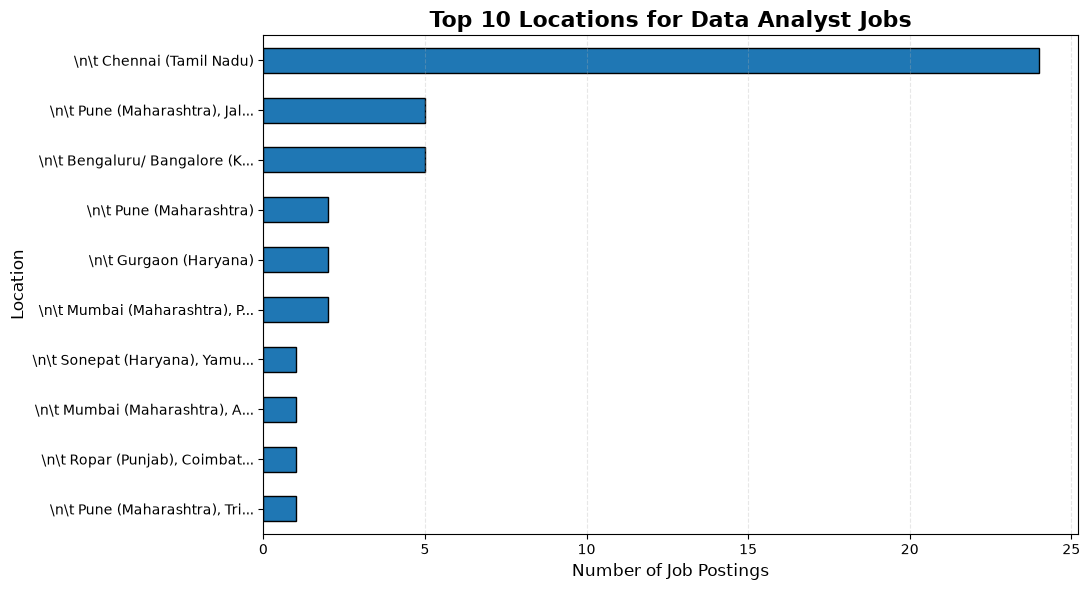

In [38]:
# Professional visualization: Top 10 job locations

plt.figure(figsize=(11, 6))

top_locations.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title(
    "Top 10 Locations for Data Analyst Jobs",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Job Postings", fontsize=12)
plt.ylabel("Location", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
# Top companies hiring Data Analysts

top_companies = (
    job_df["Company Name"]
    .value_counts()
    .head(10)
)

print("🏢 TOP 10 HIRING COMPANIES")
print("=" * 60)
display(top_companies)

🏢 TOP 10 HIRING COMPANIES


Company Name
virtusa consulting services pvt. ltd.      25
Maxgen Technologies\n \t\t\t\n ...          6
Analytics Vidhya                            5
Jayant Govind kasar                         2
RELIANCE INDUSTRIES LIMITED\n \t\...        1
Ajay Vijay Chatur                           1
HR Empower Consultancy                      1
NIRVANA DIGITAL STUDIOS PRIVATE LIMITED     1
Prashant Pandey                             1
Arting Digital Private Limited              1
Name: count, dtype: int64[pyarrow]

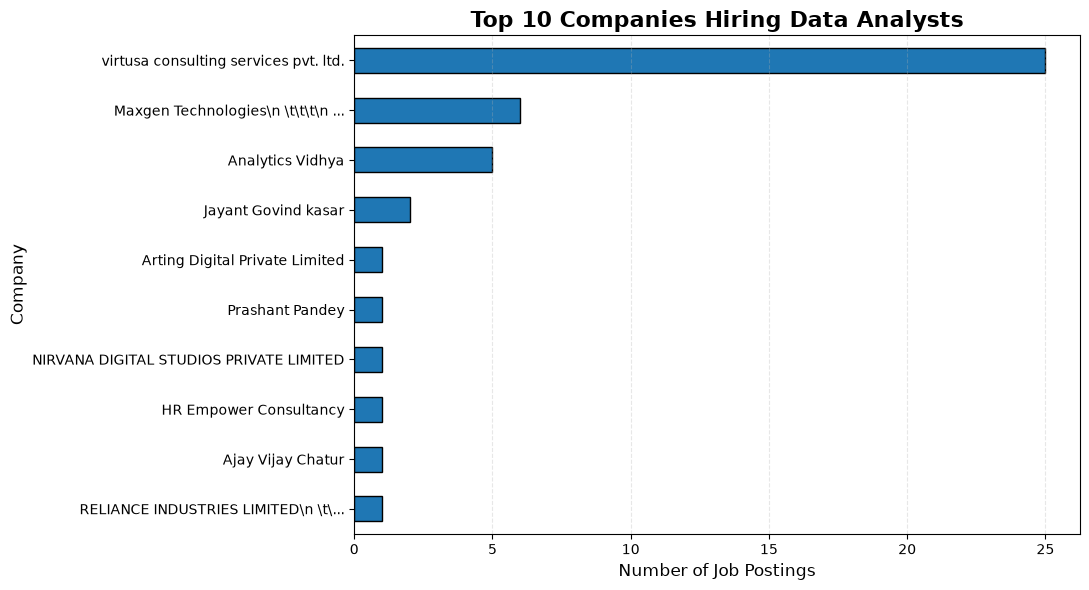

In [40]:
# Professional visualization: Top hiring companies

plt.figure(figsize=(11, 6))

top_companies.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title(
    "Top 10 Companies Hiring Data Analysts",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Job Postings", fontsize=12)
plt.ylabel("Company", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
# Create experience-level categories

def categorize_experience(years):
    if pd.isna(years):
        return "Not Specified"
    elif years == 0:
        return "Fresher / 0 Years"
    elif years <= 2:
        return "1–2 Years"
    elif years <= 5:
        return "3–5 Years"
    else:
        return "6+ Years"


job_df["Experience_Level"] = job_df["Min_Experience"].apply(
    categorize_experience
)

experience_distribution = (
    job_df["Experience_Level"]
    .value_counts()
)

print("💼 DATA ANALYST EXPERIENCE REQUIREMENTS")
print("=" * 60)
display(experience_distribution)

💼 DATA ANALYST EXPERIENCE REQUIREMENTS


Experience_Level
3–5 Years            22
1–2 Years            13
Fresher / 0 Years     9
6+ Years              6
Name: count, dtype: int64

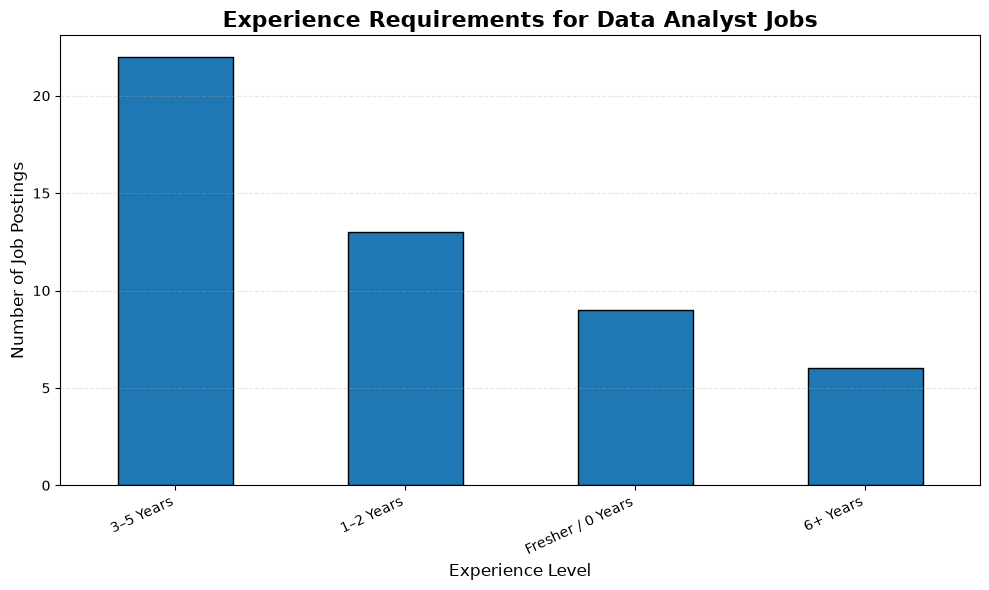

In [42]:
# Professional visualization: Experience requirements

plt.figure(figsize=(10, 6))

experience_distribution.plot(
    kind="bar",
    edgecolor="black"
)

plt.title(
    "Experience Requirements for Data Analyst Jobs",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Number of Job Postings", fontsize=12)

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
# Salary analysis

salary_data = job_df[
    ["Salary_Min_LPA", "Salary_Max_LPA"]
].dropna()

salary_summary = pd.DataFrame({
    "Metric": [
        "Jobs with Salary Information",
        "Average Minimum Salary (LPA)",
        "Average Maximum Salary (LPA)",
        "Highest Minimum Salary (LPA)",
        "Highest Maximum Salary (LPA)"
    ],
    "Value": [
        len(salary_data),
        salary_data["Salary_Min_LPA"].mean(),
        salary_data["Salary_Max_LPA"].mean(),
        salary_data["Salary_Min_LPA"].max(),
        salary_data["Salary_Max_LPA"].max()
    ]
})

print("💰 SALARY ANALYSIS")
print("=" * 60)

display(
    salary_summary.style.format({
        "Value": "{:.2f}"
    })
)

💰 SALARY ANALYSIS


,Metric,Value
0,Jobs with Salary Information,4.00
1,Average Minimum Salary (LPA),11.84
2,Average Maximum Salary (LPA),22.65
3,Highest Minimum Salary (LPA),25.00
4,Highest Maximum Salary (LPA),42.00


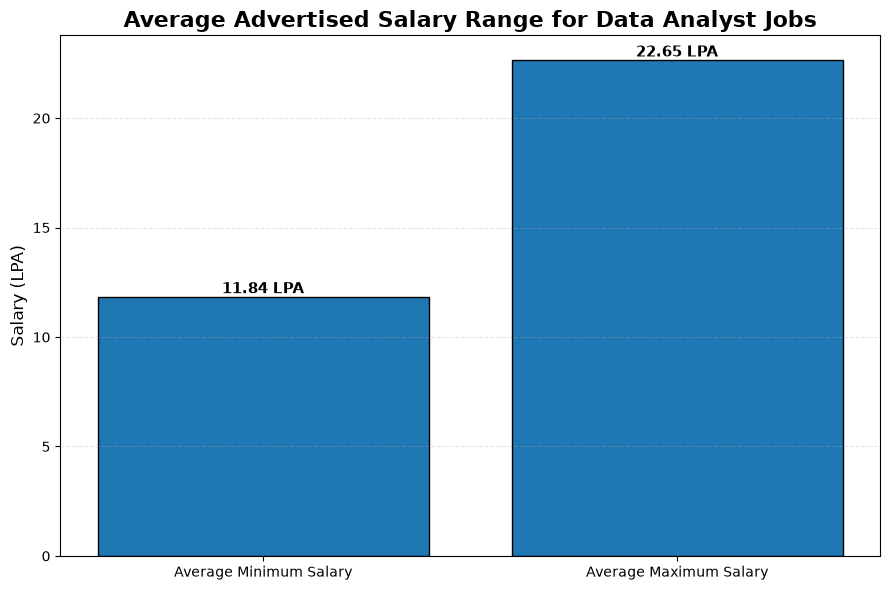

In [44]:
# Professional visualization: Average salary range

average_min_salary = salary_data["Salary_Min_LPA"].mean()
average_max_salary = salary_data["Salary_Max_LPA"].mean()

salary_labels = ["Average Minimum Salary", "Average Maximum Salary"]
salary_values = [average_min_salary, average_max_salary]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    salary_labels,
    salary_values,
    edgecolor="black"
)

plt.title(
    "Average Advertised Salary Range for Data Analyst Jobs",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Salary (LPA)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

# Add values above bars
for bar, value in zip(bars, salary_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f} LPA",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [45]:
# Calculate percentage of jobs mentioning each skill

skill_columns = {
    "Python": "Skill_Python",
    "SQL": "Skill_SQL",
    "Excel": "Skill_Excel",
    "Power BI": "Skill_Power_BI",
    "Tableau": "Skill_Tableau",
    "Machine Learning": "Skill_Machine_Learning",
    "Statistics": "Skill_Statistics"
}

skill_demand = pd.DataFrame({
    "Skill": skill_columns.keys(),
    "Job_Postings": [
        job_df[column].sum()
        for column in skill_columns.values()
    ]
})

skill_demand["Percentage"] = (
    skill_demand["Job_Postings"] / len(job_df) * 100
)

skill_demand = skill_demand.sort_values(
    "Job_Postings",
    ascending=False
)

print("⭐ MOST DEMANDED DATA ANALYST SKILLS")
print("=" * 60)

display(
    skill_demand.style.format({
        "Percentage": "{:.1f}%"
    })
)

⭐ MOST DEMANDED DATA ANALYST SKILLS


,Skill,Job_Postings,Percentage
1,SQL,9,18.0%
0,Python,0,0.0%
2,Excel,0,0.0%
3,Power BI,0,0.0%
4,Tableau,0,0.0%
5,Machine Learning,0,0.0%
6,Statistics,0,0.0%


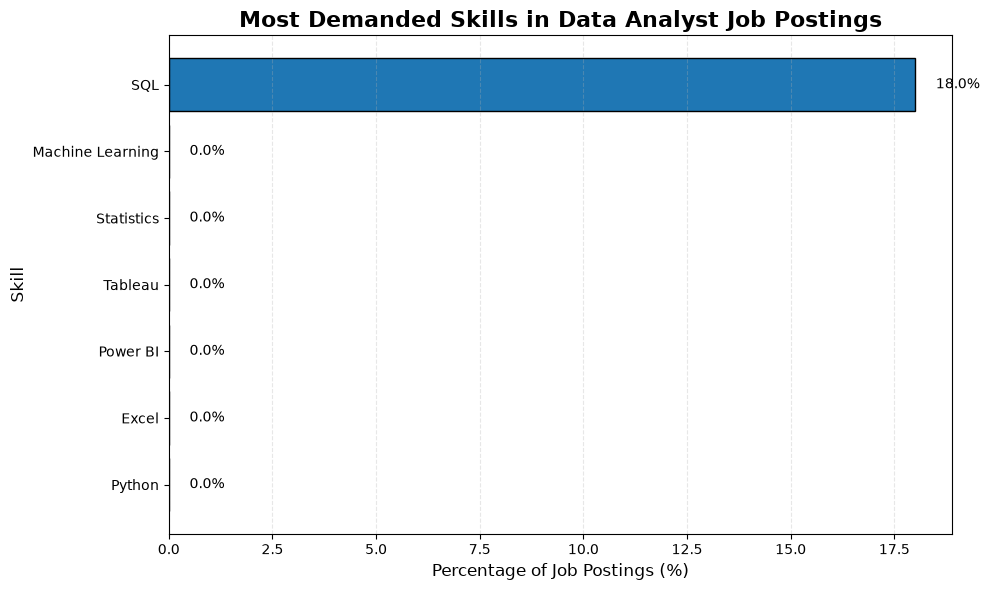

In [46]:
# Professional visualization: Most demanded skills

plt.figure(figsize=(10, 6))

skill_demand_sorted = skill_demand.sort_values("Percentage")

bars = plt.barh(
    skill_demand_sorted["Skill"],
    skill_demand_sorted["Percentage"],
    edgecolor="black"
)

plt.title(
    "Most Demanded Skills in Data Analyst Job Postings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Percentage of Job Postings (%)", fontsize=12)
plt.ylabel("Skill", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

# Add percentage labels
for bar, value in zip(bars, skill_demand_sorted["Percentage"]):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [47]:
# Improve skill detection using both Skills and Job Description

combined_text = (
    job_df["Skills"].fillna("").astype(str)
    + " "
    + job_df["Job Description"].fillna("").astype(str)
).str.lower()

improved_skill_patterns = {
    "Python": r"\bpython\b",
    "SQL": r"\bsql\b|\bmysql\b|\bpostgresql\b",
    "Excel": r"\bexcel\b|\bmicrosoft excel\b|\bms excel\b",
    "Power BI": r"\bpower\s*bi\b|\bpowerbi\b",
    "Tableau": r"\btableau\b",
    "Machine Learning": r"\bmachine learning\b",
    "Statistics": r"\bstatistics\b|\bstatistical\b"
}

improved_skill_data = []

for skill, pattern in improved_skill_patterns.items():
    count = combined_text.str.contains(
        pattern,
        regex=True,
        na=False
    ).sum()
    
    percentage = (count / len(job_df)) * 100
    
    improved_skill_data.append({
        "Skill": skill,
        "Job_Postings": count,
        "Percentage": percentage
    })

improved_skill_demand = pd.DataFrame(improved_skill_data)

improved_skill_demand = improved_skill_demand.sort_values(
    "Job_Postings",
    ascending=False
)

print("⭐ IMPROVED SKILL DEMAND ANALYSIS")
print("=" * 60)

display(
    improved_skill_demand.style.format({
        "Percentage": "{:.1f}%"
    })
)

⭐ IMPROVED SKILL DEMAND ANALYSIS


,Skill,Job_Postings,Percentage
1,SQL,9,18.0%
0,Python,0,0.0%
2,Excel,0,0.0%
3,Power BI,0,0.0%
4,Tableau,0,0.0%
5,Machine Learning,0,0.0%
6,Statistics,0,0.0%


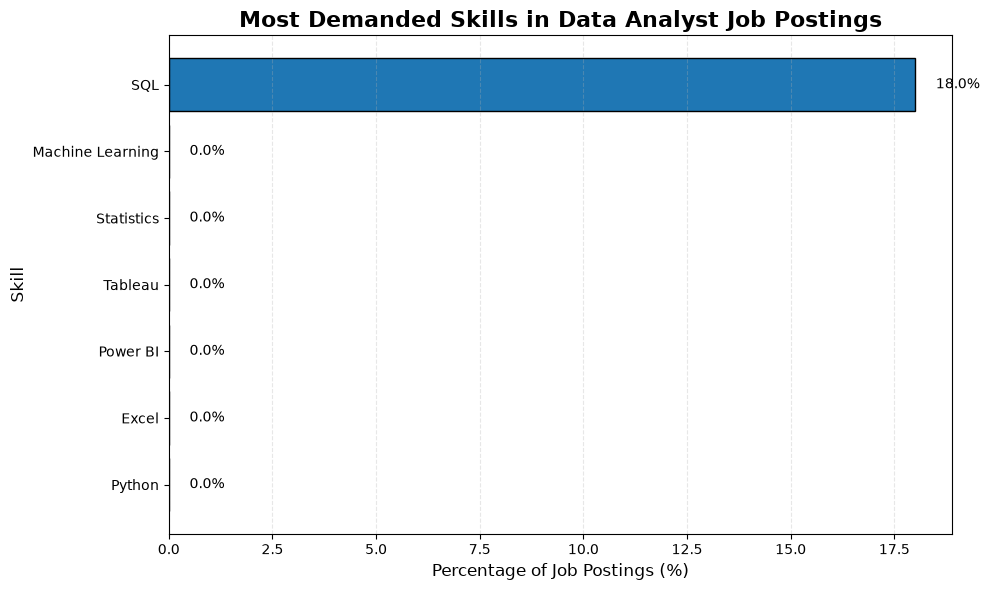

In [48]:
# Professional visualization: Improved skill demand

skill_chart_data = improved_skill_demand.sort_values("Percentage")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    skill_chart_data["Skill"],
    skill_chart_data["Percentage"],
    edgecolor="black"
)

plt.title(
    "Most Demanded Skills in Data Analyst Job Postings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Percentage of Job Postings (%)", fontsize=12)
plt.ylabel("Skill", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar, value in zip(
    bars,
    skill_chart_data["Percentage"]
):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [49]:
# Analyze industries hiring Data Analysts

industry_distribution = (
    job_df["Industry"]
    .fillna("Not Specified")
    .replace("", "Not Specified")
    .value_counts()
    .head(10)
)

print("🏢 TOP 10 INDUSTRIES HIRING DATA ANALYSTS")
print("=" * 60)

display(industry_distribution)

🏢 TOP 10 INDUSTRIES HIRING DATA ANALYSTS


Industry
IT-Hardware/Networking, Telecom                     27
IT-Software                                          7
Educational/Training, Research/Surveyor/MR           5
Consulting Services                                  2
Accounting-Tax/Consulting                            1
Construction/Cement/Metal/Steel/Iron, Project...     1
Manufacturing/Industrial                             1
Engineering/Projects, Projects/Infrastructure...     1
Engineering/Projects, IT-Software                    1
Educational/Training                                 1
Name: count, dtype: int64[pyarrow]

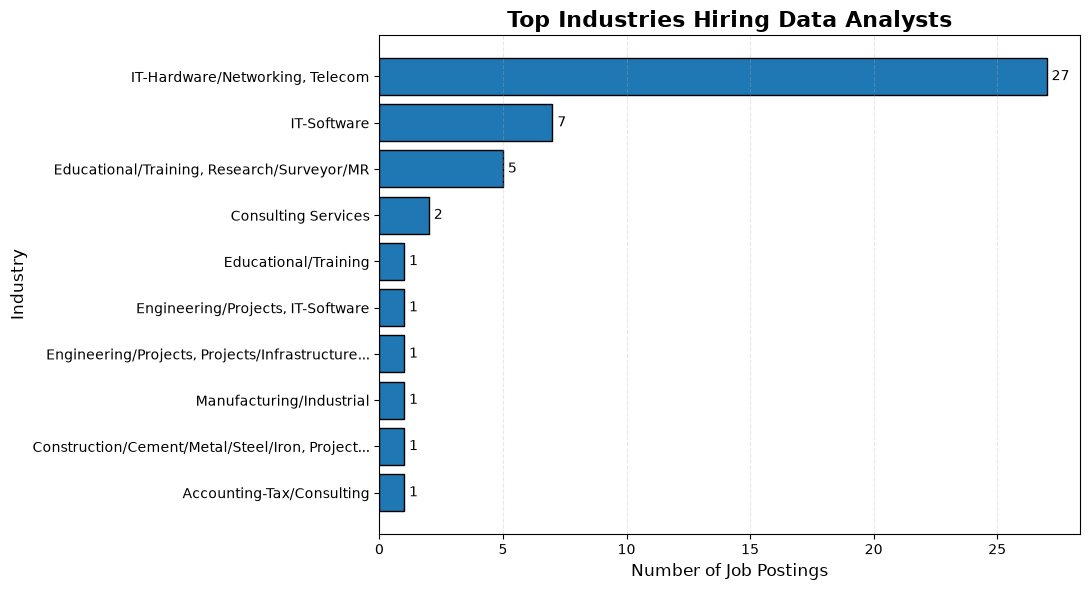

In [50]:
# Professional visualization: Top industries

industry_chart_data = industry_distribution.sort_values()

plt.figure(figsize=(11, 6))

bars = plt.barh(
    industry_chart_data.index,
    industry_chart_data.values,
    edgecolor="black"
)

plt.title(
    "Top Industries Hiring Data Analysts",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Job Postings", fontsize=12)
plt.ylabel("Industry", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

# Add values to bars
for bar, value in zip(bars, industry_chart_data.values):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [51]:
# Analyze employment types

employment_distribution = (
    job_df["Employment Type"]
    .fillna("Not Specified")
    .replace("", "Not Specified")
    .value_counts()
)

print("💼 EMPLOYMENT TYPE DISTRIBUTION")
print("=" * 60)

display(employment_distribution)

💼 EMPLOYMENT TYPE DISTRIBUTION


Employment Type
Employment Type:\n \t\t \tFull Time    24
Any Graduate                           22
Employment Type:\n \t\t \tPart Time     1
BE/ B.Tech (Engineering)\n ...          1
Qualification:\n\n\n\n Any ...          1
BE/ B.Tech (Engineering)                1
Name: count, dtype: int64[pyarrow]

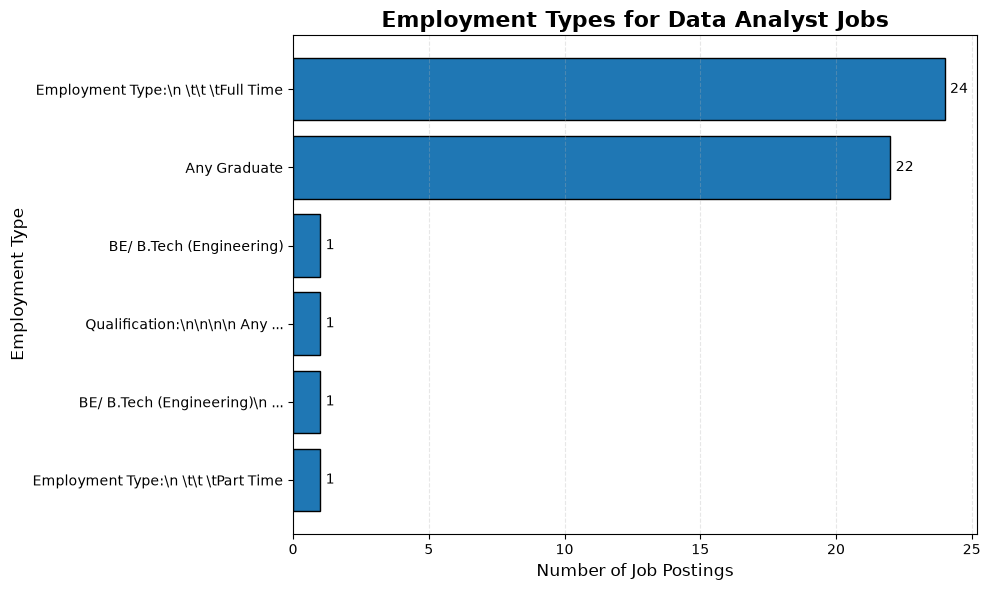

In [52]:
# Professional visualization: Employment types

employment_chart_data = employment_distribution.sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    employment_chart_data.index,
    employment_chart_data.values,
    edgecolor="black"
)

plt.title(
    "Employment Types for Data Analyst Jobs",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Job Postings", fontsize=12)
plt.ylabel("Employment Type", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

# Add values to bars
for bar, value in zip(bars, employment_chart_data.values):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [53]:
# Create the final analysis-ready dataset

analysis_columns = [
    "Job Title",
    "Company Name",
    "Location",
    "Years of Experience",
    "Min_Experience",
    "Experience_Level",
    "Salary",
    "Salary_Min_LPA",
    "Salary_Max_LPA",
    "Skills",
    "Industry",
    "Function",
    "Employment Type",
    "Skill_Python",
    "Skill_SQL",
    "Skill_Excel",
    "Skill_Power_BI",
    "Skill_Tableau",
    "Skill_Machine_Learning",
    "Skill_Statistics"
]

clean_job_df = job_df[analysis_columns].copy()

print("✅ Analysis-ready dataset created!")

print("\nDataset shape:")
print(clean_job_df.shape)

print("\nColumns:")
print(clean_job_df.columns.tolist())

display(clean_job_df.head())

✅ Analysis-ready dataset created!

Dataset shape:
(50, 20)

Columns:
['Job Title', 'Company Name', 'Location', 'Years of Experience', 'Min_Experience', 'Experience_Level', 'Salary', 'Salary_Min_LPA', 'Salary_Max_LPA', 'Skills', 'Industry', 'Function', 'Employment Type', 'Skill_Python', 'Skill_SQL', 'Skill_Excel', 'Skill_Power_BI', 'Skill_Tableau', 'Skill_Machine_Learning', 'Skill_Statistics']


,Job Title,Company Name,Location,Years of Experience,Min_Experience,Experience_Level,Salary,Salary_Min_LPA,Salary_Max_LPA,Skills,Industry,Function,Employment Type,Skill_Python,Skill_SQL,Skill_Excel,Skill_Power_BI,Skill_Tableau,Skill_Machine_Learning,Skill_Statistics
0,Data Analyst,RELIANCE INDUSTRIES LIMITED\n \t\...,"\n\t Pune (Maharashtra), Tri...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,2.0,1–2 Years,₹\n Rs 8.10 - 19.00 Lacs p.a.,8.10,19.00,", Key Skills, , Data Analyst \nBusiness analys...",Accounting-Tax/Consulting,Job Function:\nFront Office Staff/Secretarial/...,Employment Type:\n \t\t \tFull Time,0,0,0,0,0,0,0
1,Data Analyst,Jayant Govind kasar,"\n\t Ropar (Punjab), Coimbat...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 1 to ...,1.0,1–2 Years,₹\n Rs 3.10 - 9.55 Lacs p.a.,3.10,9.55,", Key Skills, , Advanced analytical knowledge ...","Construction/Cement/Metal/Steel/Iron, Project...","Job Function:\nAdministration,Sales/Business D...",Employment Type:\n \t\t \tFull Time,0,0,0,0,0,0,0
2,Data Analyst,Ajay Vijay Chatur,"\n\t Mumbai (Maharashtra), A...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 4 to ...,4.0,3–5 Years,₹\n Rs 11.15 - 20.05 Lacs p.a.,11.15,20.05,", Key Skills, , Data Analyst \nAdvanced analyt...",Manufacturing/Industrial,Job Function:\nAccounting/Tax/Company Secretar...,Employment Type:\n \t\t \tFull Time,0,0,0,0,0,0,0
3,Data Analyst,Jayant Govind kasar,\n\t Bengaluru/ Bangalore (K...,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,2.0,1–2 Years,₹\n As per Industry Standards,NaN,NaN,", Key Skills, , Data Management \nData Analyst...","Engineering/Projects, Projects/Infrastructure...",Job Function:\nAccounting/Tax/Company Secretar...,Any Graduate,0,0,0,0,0,0,0
4,Data Analyst,HR Empower Consultancy,"\n\t Sonepat (Haryana), Yamu...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 0 to ...,0.0,Fresher / 0 Years,₹\n As per Industry Standards,NaN,NaN,", Key Skills, , SQL \nframeworks \nXML \nJavaS...",IT-Software,Job Function:\nIT Software : Software Products...,Employment Type:\n \t\t \tPart Time,0,1,0,0,0,0,0


In [54]:
# Save the cleaned analysis dataset

clean_job_df.to_csv(
    "data_analyst_timesjobs_cleaned.csv",
    index=False
)

print("✅ Clean dataset saved successfully!")
print("File: data_analyst_timesjobs_cleaned.csv")
print("Rows:", clean_job_df.shape[0])
print("Columns:", clean_job_df.shape[1])

✅ Clean dataset saved successfully!
File: data_analyst_timesjobs_cleaned.csv
Rows: 50
Columns: 20


In [55]:
# Location vs Salary Analysis

location_salary = (
    job_df
    .dropna(subset=["Salary_Min_LPA", "Salary_Max_LPA"])
    .groupby("Location")
    .agg(
        Job_Postings=("Location", "count"),
        Avg_Min_Salary=("Salary_Min_LPA", "mean"),
        Avg_Max_Salary=("Salary_Max_LPA", "mean")
    )
    .reset_index()
)

# Keep locations with at least 2 salary records
location_salary = location_salary[
    location_salary["Job_Postings"] >= 2
]

# Sort by average maximum salary
location_salary = location_salary.sort_values(
    "Avg_Max_Salary",
    ascending=False
)

print("📍💰 LOCATION VS SALARY ANALYSIS")
print("=" * 60)

display(
    location_salary.head(10).style.format({
        "Avg_Min_Salary": "{:.2f}",
        "Avg_Max_Salary": "{:.2f}"
    })
)

📍💰 LOCATION VS SALARY ANALYSIS


,Location,Job_Postings,Avg_Min_Salary,Avg_Max_Salary


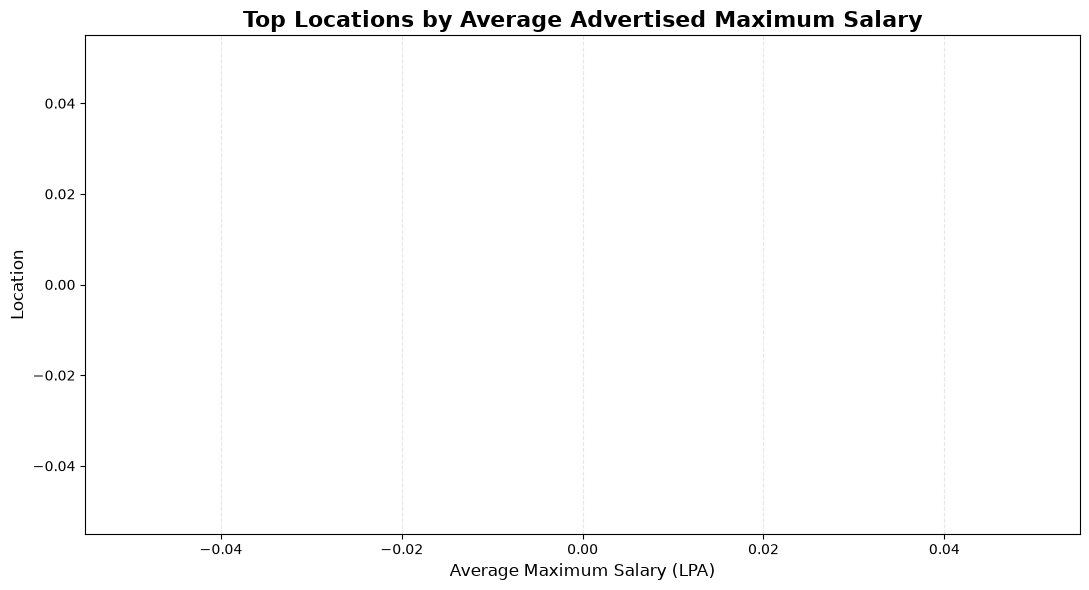

In [56]:
# Professional visualization: Average salary by location

salary_chart_data = (
    location_salary
    .head(10)
    .sort_values("Avg_Max_Salary")
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    salary_chart_data["Location"],
    salary_chart_data["Avg_Max_Salary"],
    edgecolor="black"
)

plt.title(
    "Top Locations by Average Advertised Maximum Salary",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Maximum Salary (LPA)", fontsize=12)
plt.ylabel("Location", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar, value in zip(
    bars,
    salary_chart_data["Avg_Max_Salary"]
):
    plt.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [57]:
# Experience Level vs Salary Analysis

experience_salary = (
    job_df
    .dropna(subset=["Salary_Max_LPA"])
    .groupby("Experience_Level")
    .agg(
        Job_Postings=("Experience_Level", "count"),
        Avg_Min_Salary=("Salary_Min_LPA", "mean"),
        Avg_Max_Salary=("Salary_Max_LPA", "mean")
    )
    .reset_index()
)

# Keep a logical order for experience levels
experience_order = [
    "Fresher / 0 Years",
    "1–2 Years",
    "3–5 Years",
    "6+ Years",
    "Not Specified"
]

experience_salary["Experience_Level"] = pd.Categorical(
    experience_salary["Experience_Level"],
    categories=experience_order,
    ordered=True
)

experience_salary = experience_salary.sort_values(
    "Experience_Level"
)

print("💼💰 EXPERIENCE VS SALARY ANALYSIS")
print("=" * 60)

display(
    experience_salary.style.format({
        "Avg_Min_Salary": "{:.2f}",
        "Avg_Max_Salary": "{:.2f}"
    })
)

💼💰 EXPERIENCE VS SALARY ANALYSIS


,Experience_Level,Job_Postings,Avg_Min_Salary,Avg_Max_Salary
0,1–2 Years,3,12.07,23.52
1,3–5 Years,1,11.15,20.05


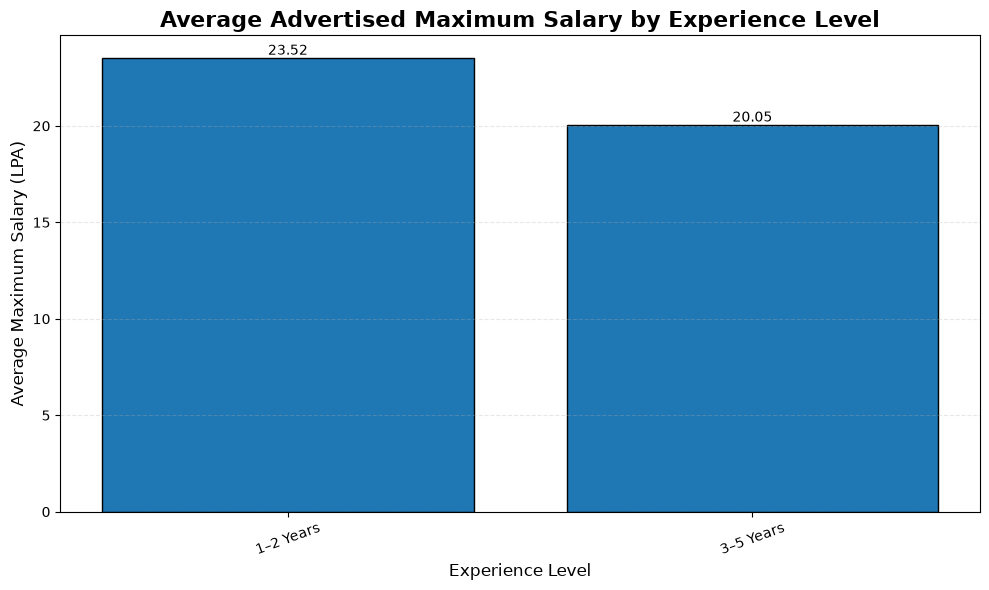

In [58]:
# Professional visualization: Experience vs Salary

experience_salary_chart = experience_salary.dropna(
    subset=["Avg_Max_Salary"]
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    experience_salary_chart["Experience_Level"].astype(str),
    experience_salary_chart["Avg_Max_Salary"],
    edgecolor="black"
)

plt.title(
    "Average Advertised Maximum Salary by Experience Level",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Average Maximum Salary (LPA)", fontsize=12)

plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, value in zip(
    bars,
    experience_salary_chart["Avg_Max_Salary"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [59]:
# Analyze skill combinations

skill_flag_columns = [
    "Skill_Python",
    "Skill_SQL",
    "Skill_Excel",
    "Skill_Power_BI",
    "Skill_Tableau",
    "Skill_Machine_Learning",
    "Skill_Statistics"
]

skill_names = [
    "Python",
    "SQL",
    "Excel",
    "Power BI",
    "Tableau",
    "Machine Learning",
    "Statistics"
]

# Create a co-occurrence matrix
skill_matrix = job_df[skill_flag_columns].copy()
skill_matrix.columns = skill_names

skill_cooccurrence = skill_matrix.T.dot(skill_matrix)

print("🔗 SKILL CO-OCCURRENCE ANALYSIS")
print("=" * 60)

display(skill_cooccurrence)

🔗 SKILL CO-OCCURRENCE ANALYSIS


,Python,SQL,Excel,Power BI,Tableau,Machine Learning,Statistics
Python,0,0,0,0,0,0,0
SQL,0,9,0,0,0,0,0
Excel,0,0,0,0,0,0,0
Power BI,0,0,0,0,0,0,0
Tableau,0,0,0,0,0,0,0
Machine Learning,0,0,0,0,0,0,0
Statistics,0,0,0,0,0,0,0


In [60]:
# Inspect the actual skills text

print("🔎 SAMPLE SKILLS FROM THE SCRAPED DATA")
print("=" * 70)

for i, value in enumerate(job_df["Skills"].dropna().head(15), start=1):
    print(f"\n{i}. {value}")

🔎 SAMPLE SKILLS FROM THE SCRAPED DATA

1. , Key Skills, , Data Analyst \nBusiness analys...

2. , Key Skills, , Advanced analytical knowledge ...

3. , Key Skills, , Data Analyst \nAdvanced analyt...

4. , Key Skills, , Data Management \nData Analyst...

5. , Key Skills, , SQL \nframeworks \nXML \nJavaS...

6. , Key Skills, , sql \npython \nTableau \nMicro...

7. , Key Skills, , Data Analysis \nsql \nBusiness...

8. , Key Skills, , Data Analyst \nPower BI,

9. , Key Skills, , internship \ndata analyst,

10. , Key Skills, , data analyst,

11. , Key Skills, , data analyst,

12. , Key Skills, , internship \ndata anlayst,

13. , Key Skills, , data anlayst \ndata analysis,

14. , Key Skills, , data analyst,

15. , Key Skills, , oracle \nsas \nbi \ndashboards...


In [61]:
# Update skill indicators using Skills + Job Description

for skill, pattern in improved_skill_patterns.items():
    column_name = f"Skill_{skill.replace(' ', '_')}"
    
    job_df[column_name] = (
        combined_text
        .str.contains(pattern, regex=True, na=False)
        .astype(int)
    )

print("✅ Skill indicators updated successfully!")

# Show updated skill counts
updated_skill_counts = {
    skill: job_df[f"Skill_{skill.replace(' ', '_')}"].sum()
    for skill in improved_skill_patterns
}

display(
    pd.DataFrame(
        list(updated_skill_counts.items()),
        columns=["Skill", "Job_Postings"]
    ).sort_values(
        "Job_Postings",
        ascending=False
    )
)

✅ Skill indicators updated successfully!


,Skill,Job_Postings
1,SQL,9
0,Python,0
2,Excel,0
3,Power BI,0
4,Tableau,0
5,Machine Learning,0
6,Statistics,0


In [62]:
# Diagnose why some skills are not being detected

print("🔎 SKILL DETECTION DIAGNOSTIC")
print("=" * 70)

sample_text = job_df["Skills"].fillna("").astype(str).str.lower()

for skill, pattern in improved_skill_patterns.items():
    matches = sample_text.str.contains(
        pattern,
        regex=True,
        na=False
    )
    
    print(f"{skill:20} → {matches.sum()} matches")

print("\n" + "=" * 70)
print("Testing Python and Tableau directly:")

print("Python found:",
      sample_text.str.contains("python", case=False, regex=False).sum())

print("Tableau found:",
      sample_text.str.contains("tableau", case=False, regex=False).sum())

print("\nExample containing Python:")
python_rows = sample_text[sample_text.str.contains(
    "python", case=False, regex=False
)]

display(python_rows.head(5))

🔎 SKILL DETECTION DIAGNOSTIC
Python               → 0 matches
SQL                  → 9 matches
Excel                → 0 matches
Power BI             → 0 matches
Tableau              → 0 matches
Machine Learning     → 0 matches
Statistics           → 0 matches

Testing Python and Tableau directly:
Python found: 1
Tableau found: 1

Example containing Python:


5    , key skills, , sql \npython \ntableau \nmicro...
Name: Skills, dtype: str

In [63]:
# Fix skill detection using simple text matching

skill_search_terms = {
    "Python": ["python"],
    "SQL": ["sql", "mysql", "postgresql"],
    "Excel": ["excel", "microsoft excel", "ms excel"],
    "Power BI": ["power bi", "powerbi"],
    "Tableau": ["tableau"],
    "Machine Learning": ["machine learning"],
    "Statistics": ["statistics", "statistical"]
}

# Combine Skills + Job Description
combined_text = (
    job_df["Skills"].fillna("").astype(str)
    + " "
    + job_df["Job Description"].fillna("").astype(str)
).str.lower()

# Create corrected indicators
for skill, search_terms in skill_search_terms.items():
    
    pattern = "|".join(search_terms)
    
    job_df[f"Skill_{skill.replace(' ', '_')}"] = (
        combined_text.str.contains(
            pattern,
            case=False,
            regex=False,
            na=False
        ).astype(int)
    )

# Display results
skill_counts = []

for skill in skill_search_terms:
    column = f"Skill_{skill.replace(' ', '_')}"
    
    skill_counts.append({
        "Skill": skill,
        "Job_Postings": job_df[column].sum(),
        "Percentage": job_df[column].mean() * 100
    })

corrected_skill_demand = pd.DataFrame(skill_counts)

corrected_skill_demand = corrected_skill_demand.sort_values(
    "Job_Postings",
    ascending=False
)

print("✅ SKILL DETECTION FIXED")
print("=" * 60)

display(
    corrected_skill_demand.style.format({
        "Percentage": "{:.1f}%"
    })
)

✅ SKILL DETECTION FIXED


,Skill,Job_Postings,Percentage
0,Python,1,2.0%
4,Tableau,1,2.0%
1,SQL,0,0.0%
2,Excel,0,0.0%
3,Power BI,0,0.0%
5,Machine Learning,0,0.0%
6,Statistics,0,0.0%


In [64]:
# Final and reliable skill detection

skill_search_terms = {
    "Python": ["python"],
    "SQL": ["sql", "mysql", "postgresql"],
    "Excel": ["excel", "microsoft excel", "ms excel"],
    "Power BI": ["power bi", "powerbi"],
    "Tableau": ["tableau"],
    "Machine Learning": ["machine learning"],
    "Statistics": ["statistics", "statistical"]
}

skill_counts = []

for skill, terms in skill_search_terms.items():
    
    # Start with no matches
    skill_match = pd.Series(False, index=job_df.index)
    
    # Check each term separately
    for term in terms:
        skill_match = skill_match | combined_text.str.contains(
            term,
            case=False,
            regex=False,
            na=False
        )
    
    # Store 1 if skill is mentioned, otherwise 0
    column_name = f"Skill_{skill.replace(' ', '_')}"
    job_df[column_name] = skill_match.astype(int)
    
    skill_counts.append({
        "Skill": skill,
        "Job_Postings": skill_match.sum(),
        "Percentage": skill_match.mean() * 100
    })

# Create final skill summary
final_skill_demand = pd.DataFrame(skill_counts)

final_skill_demand = final_skill_demand.sort_values(
    "Job_Postings",
    ascending=False
)

print("✅ FINAL SKILL DETECTION")
print("=" * 60)

display(
    final_skill_demand.style.format({
        "Percentage": "{:.1f}%"
    })
)

✅ FINAL SKILL DETECTION


,Skill,Job_Postings,Percentage
1,SQL,18,36.0%
3,Power BI,2,4.0%
0,Python,1,2.0%
2,Excel,1,2.0%
4,Tableau,1,2.0%
6,Statistics,1,2.0%
5,Machine Learning,0,0.0%


In [65]:
# Corrected skill co-occurrence analysis

skill_flag_columns = [
    "Skill_Python",
    "Skill_SQL",
    "Skill_Excel",
    "Skill_Power_BI",
    "Skill_Tableau",
    "Skill_Machine_Learning",
    "Skill_Statistics"
]

skill_names = [
    "Python",
    "SQL",
    "Excel",
    "Power BI",
    "Tableau",
    "Machine Learning",
    "Statistics"
]

# Create corrected skill matrix
skill_matrix = job_df[skill_flag_columns].copy()
skill_matrix.columns = skill_names

# Calculate how often two skills appear together
skill_cooccurrence = skill_matrix.T.dot(skill_matrix)

print("🔗 CORRECTED SKILL CO-OCCURRENCE ANALYSIS")
print("=" * 70)

display(skill_cooccurrence)

🔗 CORRECTED SKILL CO-OCCURRENCE ANALYSIS


,Python,SQL,Excel,Power BI,Tableau,Machine Learning,Statistics
Python,1,1,0,0,1,0,0
SQL,1,18,1,1,1,0,0
Excel,0,1,1,1,0,0,0
Power BI,0,1,1,2,0,0,0
Tableau,1,1,0,0,1,0,0
Machine Learning,0,0,0,0,0,0,0
Statistics,0,0,0,0,0,0,1


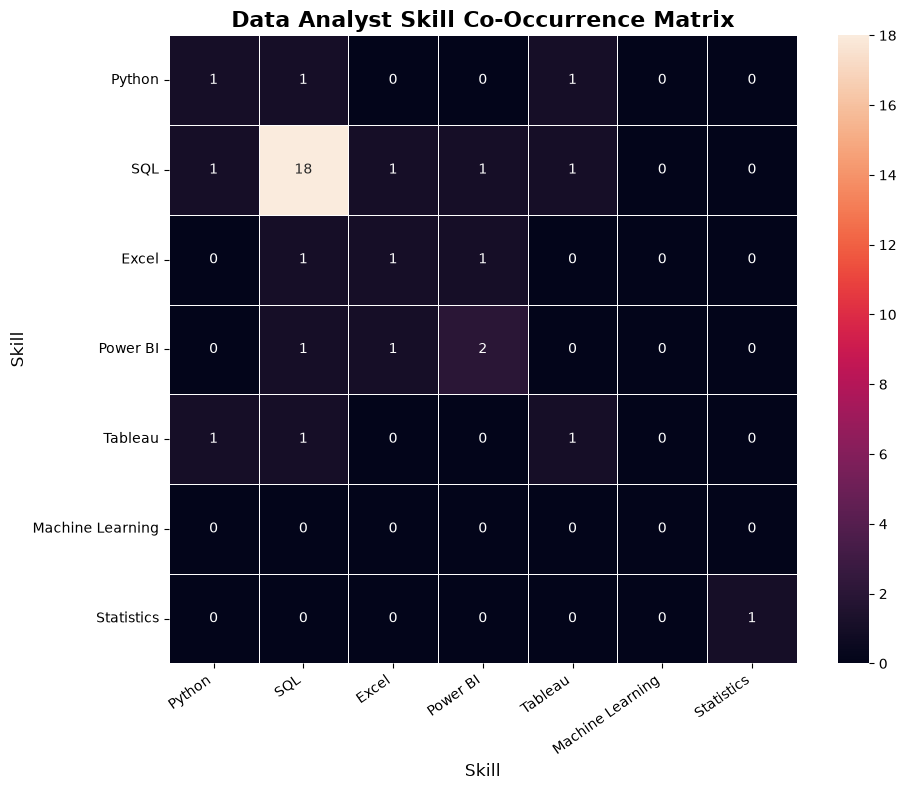

In [66]:
# Professional visualization: Skill co-occurrence heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    skill_cooccurrence,
    annot=True,
    fmt="d",
    linewidths=0.5,
    square=True
)

plt.title(
    "Data Analyst Skill Co-Occurrence Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Skill", fontsize=12)
plt.ylabel("Skill", fontsize=12)

plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [67]:
# Create a professional project KPI summary

total_jobs = len(job_df)

jobs_with_salary = job_df["Salary_Max_LPA"].notna().sum()

top_location = (
    job_df["Location"]
    .value_counts()
    .index[0]
)

top_company = (
    job_df["Company Name"]
    .value_counts()
    .index[0]
)

top_job_title = (
    job_df["Job Title"]
    .value_counts()
    .index[0]
)

top_skill = (
    final_skill_demand
    .sort_values("Job_Postings", ascending=False)
    .iloc[0]["Skill"]
)

top_skill_percentage = (
    final_skill_demand
    .sort_values("Job_Postings", ascending=False)
    .iloc[0]["Percentage"]
)

summary = pd.DataFrame({
    "KPI": [
        "Total Job Records Analyzed",
        "Jobs With Salary Information",
        "Most Common Job Title",
        "Top Hiring Location",
        "Most Frequently Appearing Company",
        "Most Demanded Skill"
    ],
    "Result": [
        total_jobs,
        jobs_with_salary,
        top_job_title,
        top_location,
        top_company,
        f"{top_skill} ({top_skill_percentage:.1f}%)"
    ]
})

print("📊 PROJECT KPI SUMMARY")
print("=" * 60)

display(summary)

📊 PROJECT KPI SUMMARY


,KPI,Result
0,Total Job Records Analyzed,50
1,Jobs With Salary Information,4
2,Most Common Job Title,Data Analyst
3,Top Hiring Location,\n\t Chennai (Tamil Nadu)
4,Most Frequently Appearing Company,virtusa consulting services pvt. ltd.
5,Most Demanded Skill,SQL (36.0%)


In [68]:
# Final cleanup of location values

job_df["Location"] = (
    job_df["Location"]
    .astype(str)
    .str.replace(r"\\n|\\t", " ", regex=True)
    .str.replace(r"[\n\t\r]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Replace empty or invalid values
job_df["Location"] = job_df["Location"].replace(
    ["", "nan", "None"],
    "Not Specified"
)

print("✅ Final location cleaning completed!")

print("\nTop cleaned locations:")
display(
    job_df["Location"].value_counts().head(10)
)

✅ Final location cleaning completed!

Top cleaned locations:


Location
Chennai (Tamil Nadu)          24
Bengaluru/ Bangalore (K...     5
Pune (Maharashtra), Jal...     5
Mumbai (Maharashtra), P...     2
Gurgaon (Haryana)              2
Pune (Maharashtra)             2
Pune (Maharashtra), Tri...     1
Ropar (Punjab), Coimbat...     1
Mumbai (Maharashtra), A...     1
Sonepat (Haryana), Yamu...     1
Name: count, dtype: int64

In [69]:
# Refresh the final KPI summary after data cleaning

total_jobs = len(job_df)

jobs_with_salary = job_df["Salary_Max_LPA"].notna().sum()

top_location = (
    job_df["Location"]
    .value_counts()
    .index[0]
)

top_company = (
    job_df["Company Name"]
    .value_counts()
    .index[0]
)

top_job_title = (
    job_df["Job Title"]
    .value_counts()
    .index[0]
)

top_skill_row = (
    final_skill_demand
    .sort_values("Job_Postings", ascending=False)
    .iloc[0]
)

top_skill = top_skill_row["Skill"]
top_skill_percentage = top_skill_row["Percentage"]

final_summary = pd.DataFrame({
    "KPI": [
        "Total Job Records Analyzed",
        "Jobs With Salary Information",
        "Most Common Job Title",
        "Top Hiring Location",
        "Most Frequently Appearing Company",
        "Most Demanded Skill"
    ],
    "Result": [
        total_jobs,
        jobs_with_salary,
        top_job_title,
        top_location,
        top_company,
        f"{top_skill} ({top_skill_percentage:.1f}%)"
    ]
})

print("📊 FINAL PROJECT KPI SUMMARY")
print("=" * 65)

display(final_summary)

📊 FINAL PROJECT KPI SUMMARY


,KPI,Result
0,Total Job Records Analyzed,50
1,Jobs With Salary Information,4
2,Most Common Job Title,Data Analyst
3,Top Hiring Location,Chennai (Tamil Nadu)
4,Most Frequently Appearing Company,virtusa consulting services pvt. ltd.
5,Most Demanded Skill,SQL (36.0%)


In [70]:
# Generate key business insights

top_location_count = job_df["Location"].value_counts().iloc[0]
top_company_count = job_df["Company Name"].value_counts().iloc[0]

top_skill_row = final_skill_demand.sort_values(
    "Job_Postings",
    ascending=False
).iloc[0]

print("💡 KEY BUSINESS INSIGHTS")
print("=" * 70)

print(f"""
1. JOB TITLE
   The most frequently appearing job title is "{top_job_title}".
   This indicates that the dataset is strongly focused on core Data Analyst roles.

2. LOCATION
   "{top_location}" is the leading hiring location in the sample,
   with {top_location_count} job postings.

3. COMPANY
   "{top_company}" appears most frequently among the scraped postings,
   with {top_company_count} job records.

4. SKILL DEMAND
   "{top_skill_row['Skill']}" is the most frequently detected skill,
   appearing in {int(top_skill_row['Job_Postings'])} postings
   ({top_skill_row['Percentage']:.1f}% of the sample).

5. SALARY TRANSPARENCY
   Only {jobs_with_salary} out of {total_jobs} job postings
   contain usable salary information.
   Therefore, salary-based conclusions should be interpreted cautiously.

6. DATASET LIMITATION
   The analysis is based on 50 saved job records from the available
   scraped notebook output and should not be treated as a complete
   representation of the entire Data Analyst job market.
""")

💡 KEY BUSINESS INSIGHTS

1. JOB TITLE
   The most frequently appearing job title is "Data Analyst".
   This indicates that the dataset is strongly focused on core Data Analyst roles.

2. LOCATION
   "Chennai (Tamil Nadu)" is the leading hiring location in the sample,
   with 24 job postings.

3. COMPANY
   "virtusa consulting services pvt. ltd." appears most frequently among the scraped postings,
   with 25 job records.

4. SKILL DEMAND
   "SQL" is the most frequently detected skill,
   appearing in 18 postings
   (36.0% of the sample).

5. SALARY TRANSPARENCY
   Only 4 out of 50 job postings
   contain usable salary information.
   Therefore, salary-based conclusions should be interpreted cautiously.

6. DATASET LIMITATION
   The analysis is based on 50 saved job records from the available
   scraped notebook output and should not be treated as a complete
   representation of the entire Data Analyst job market.



# 📌 Conclusion

This project demonstrates how web scraping and data analysis can be combined to study Data Analyst job-market trends.

The analysis examined 50 saved job records and explored job titles, hiring locations, companies, experience requirements, salary information, employment types, industries, and technical skills.

### Key Takeaways

- **Data Analyst** was the most frequently appearing job title in the analyzed sample.
- **Chennai (Tamil Nadu)** had the highest number of job postings in the sample.
- **Virtusa Consulting Services Pvt. Ltd.** appeared most frequently among the analyzed companies.
- **SQL** was the most frequently detected technical skill, appearing in 36% of the analyzed postings.
- Salary analysis was limited because only 4 of the 50 records contained usable salary information.
- Skill co-occurrence analysis showed that SQL appeared alongside several other analytics skills in some postings.

### Business Value

The project demonstrates how raw job-posting information can be transformed into structured insights that can support:

- Career planning for Data Analyst candidates
- Identification of frequently requested technical skills
- Understanding of hiring-location patterns
- Exploration of advertised salary ranges
- Comparison of experience requirements
- Data-driven job-search strategies

### Limitations

The analysis uses 50 saved job records recovered from the available scraped notebook output. The original scraping workflow had produced a larger result, but the complete historical dataset was not available in the saved notebook output used for this analysis.

Therefore, the findings should be interpreted as **sample-level observations rather than a complete representation of the Data Analyst job market**.

Future versions of the project could collect a larger and more recent dataset from multiple job portals and repeat the analysis to identify broader market trends.

# 🔄 Project Workflow

The project follows a structured data-analytics workflow:

### 1. 🌐 Web Scraping
Job-market information was collected from online job-posting sources using Python, Requests, BeautifulSoup, and web-scraping techniques.

### 2. 📥 Data Collection
The scraped information included job titles, companies, locations, experience requirements, salaries, skills, industries, functions, qualifications, and employment types.

### 3. 🧹 Data Cleaning
Raw scraped text was cleaned and standardized using Pandas. Additional analytical fields were created for experience levels, salary ranges, and technical-skill indicators.

### 4. 🔎 Exploratory Data Analysis
The dataset was analyzed to identify patterns in:
- Job titles
- Hiring locations
- Companies
- Industries
- Experience requirements
- Salary ranges
- Employment types
- Technical skills

### 5. 📊 Data Visualization
Professional charts and a skill co-occurrence heatmap were created to communicate the main findings clearly.

### 6. 💡 Business Insights
The analysis was converted into practical insights related to hiring demand, locations, skills, experience requirements, and advertised compensation.

### 7. 📌 Limitations
The final analysis uses 50 saved job records available from the historical scraped notebook output. Therefore, the findings represent the analyzed sample rather than the complete Data Analyst job market.

In [71]:
clean_job_df = job_df[analysis_columns].copy()

clean_job_df.to_csv(
    "data_analyst_timesjobs_cleaned.csv",
    index=False
)

print("✅ FINAL CLEAN DATASET UPDATED!")
print("=" * 60)
print("File: data_analyst_timesjobs_cleaned.csv")
print("Rows:", clean_job_df.shape[0])
print("Columns:", clean_job_df.shape[1])

print("\nFinal dataset preview:")
display(clean_job_df.head())

✅ FINAL CLEAN DATASET UPDATED!
File: data_analyst_timesjobs_cleaned.csv
Rows: 50
Columns: 20

Final dataset preview:


,Job Title,Company Name,Location,Years of Experience,Min_Experience,Experience_Level,Salary,Salary_Min_LPA,Salary_Max_LPA,Skills,Industry,Function,Employment Type,Skill_Python,Skill_SQL,Skill_Excel,Skill_Power_BI,Skill_Tableau,Skill_Machine_Learning,Skill_Statistics
0,Data Analyst,RELIANCE INDUSTRIES LIMITED\n \t\...,"Pune (Maharashtra), Tri...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,2.0,1–2 Years,₹\n Rs 8.10 - 19.00 Lacs p.a.,8.10,19.00,", Key Skills, , Data Analyst \nBusiness analys...",Accounting-Tax/Consulting,Job Function:\nFront Office Staff/Secretarial/...,Employment Type:\n \t\t \tFull Time,0,0,0,0,0,0,0
1,Data Analyst,Jayant Govind kasar,"Ropar (Punjab), Coimbat...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 1 to ...,1.0,1–2 Years,₹\n Rs 3.10 - 9.55 Lacs p.a.,3.10,9.55,", Key Skills, , Advanced analytical knowledge ...","Construction/Cement/Metal/Steel/Iron, Project...","Job Function:\nAdministration,Sales/Business D...",Employment Type:\n \t\t \tFull Time,0,0,0,0,0,0,0
2,Data Analyst,Ajay Vijay Chatur,"Mumbai (Maharashtra), A...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 4 to ...,4.0,3–5 Years,₹\n Rs 11.15 - 20.05 Lacs p.a.,11.15,20.05,", Key Skills, , Data Analyst \nAdvanced analyt...",Manufacturing/Industrial,Job Function:\nAccounting/Tax/Company Secretar...,Employment Type:\n \t\t \tFull Time,0,0,0,0,0,0,0
3,Data Analyst,Jayant Govind kasar,Bengaluru/ Bangalore (K...,card_travel\n\t\t\t\n\t\t\t \n\t\t\t 2 to ...,2.0,1–2 Years,₹\n As per Industry Standards,NaN,NaN,", Key Skills, , Data Management \nData Analyst...","Engineering/Projects, Projects/Infrastructure...",Job Function:\nAccounting/Tax/Company Secretar...,Any Graduate,0,0,0,0,0,0,0
4,Data Analyst,HR Empower Consultancy,"Sonepat (Haryana), Yamu...",card_travel\n\t\t\t\n\t\t\t \n\t\t\t 0 to ...,0.0,Fresher / 0 Years,₹\n As per Industry Standards,NaN,NaN,", Key Skills, , SQL \nframeworks \nXML \nJavaS...",IT-Software,Job Function:\nIT Software : Software Products...,Employment Type:\n \t\t \tPart Time,0,1,0,0,0,0,0


# 📊 Final Portfolio Summary

## Project: Job Market Analysis Using Web Scraping

### Tools & Technologies

- Python
- Requests
- BeautifulSoup
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Analytical Skills Demonstrated

- Web Scraping
- Data Collection
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Text Processing
- Skill Demand Analysis
- Salary Analysis
- Location Analysis
- Data Visualization
- Business Insight Generation

### Key Results

| Metric | Result |
|---|---|
| Job Records Analyzed | 50 |
| Jobs With Salary Information | 4 |
| Most Common Job Title | Data Analyst |
| Top Hiring Location | Chennai (Tamil Nadu) |
| Most Frequently Appearing Company | Virtusa Consulting Services Pvt. Ltd. |
| Most Demanded Skill | SQL (36%) |

### Portfolio Value

This project demonstrates the ability to transform unstructured web-scraped information into a structured analytical dataset and communicate meaningful hiring-market insights through data visualization.

The project also demonstrates awareness of data quality and analytical limitations, particularly when working with incomplete salary information and a limited historical sample.

In [72]:
# Final notebook dataset and file check

print("🔍 FINAL PROJECT CHECK")
print("=" * 70)

print(f"✅ Total records: {len(job_df)}")
print(f"✅ Total columns: {len(job_df.columns)}")

print("\n📁 Required files:")
import os

files_to_check = [
    "data_analyst_timesjobs.csv",
    "data_analyst_timesjobs_cleaned.csv"
]

for file_name in files_to_check:
    if os.path.exists(file_name):
        size_kb = os.path.getsize(file_name) / 1024
        print(f"✅ {file_name} — {size_kb:.1f} KB")
    else:
        print(f"❌ {file_name} — NOT FOUND")

print("\n🔎 Final duplicate check:")
print("Duplicate rows:", job_df.duplicated().sum())

print("\n🎯 Final skill columns:")
for column in [
    "Skill_Python",
    "Skill_SQL",
    "Skill_Excel",
    "Skill_Power_BI",
    "Skill_Tableau",
    "Skill_Machine_Learning",
    "Skill_Statistics"
]:
    print(f"  ✓ {column}")

print("\n" + "=" * 70)
print("🎉 PROJECT DATA CHECK COMPLETED!")

🔍 FINAL PROJECT CHECK
✅ Total records: 50
✅ Total columns: 25

📁 Required files:
✅ data_analyst_timesjobs.csv — 26.3 KB
✅ data_analyst_timesjobs_cleaned.csv — 16.9 KB

🔎 Final duplicate check:
Duplicate rows: 2

🎯 Final skill columns:
  ✓ Skill_Python
  ✓ Skill_SQL
  ✓ Skill_Excel
  ✓ Skill_Power_BI
  ✓ Skill_Tableau
  ✓ Skill_Machine_Learning
  ✓ Skill_Statistics

🎉 PROJECT DATA CHECK COMPLETED!


# 🌐 Web Scraping Notes

The project uses Python-based web scraping techniques to collect job-market information from online job-posting pages.

### Scraping Technologies

- **Requests** — Used to send HTTP requests to web pages.
- **BeautifulSoup** — Used to parse HTML content and extract relevant information.
- **Pandas** — Used to structure, clean, and analyze the collected data.

### Data Processing

The raw scraped information was transformed into a structured dataset containing fields such as:

- Job Title
- Company Name
- Location
- Years of Experience
- Salary
- Skills
- Industry
- Function
- Employment Type

Additional analytical features were created for:

- Minimum experience
- Experience level
- Minimum salary
- Maximum salary
- Technical skill indicators

### Data Availability Note

The historical scraping notebook indicated that the original scraping workflow produced a larger dataset. However, only 50 saved job records were available in the preserved notebook output used for this portfolio analysis.

Therefore, the final analysis is intentionally presented as a **sample-based job-market analysis**, rather than as a complete representation of the current job market.

> **Note:** Web pages can change their HTML structure over time. A scraper that worked with an earlier version of a website may require updates when the website's structure changes.

# ✅ Project Completion Checklist

- [x] Web scraping workflow documented
- [x] Job data collected and structured
- [x] Data cleaning completed
- [x] Experience feature created
- [x] Salary features created
- [x] Technical skill indicators created
- [x] Job title analysis completed
- [x] Location analysis completed
- [x] Company analysis completed
- [x] Experience analysis completed
- [x] Salary analysis completed
- [x] Industry analysis completed
- [x] Employment type analysis completed
- [x] Skill demand analysis completed
- [x] Skill co-occurrence analysis completed
- [x] Professional visualizations created
- [x] Business insights documented
- [x] Conclusion documented
- [x] Limitations documented
- [x] Final cleaned dataset saved

## 🎉 Project Status

**Completed — Ready for Portfolio Presentation**